# Example of using fuctions from package tools

Set up the path for the execution.

In [ ]:
import sys
import os
import pandas as pd
from emtk import parsers, visualization, util, aoi
from tools import setup_paths, path_similarity, auxiliary

paths = setup_paths()
lib_path = paths["lib_path"]

Parse the data.

In [13]:
# Parse corrected EMIP data - now directly returns a DataFrame ready for build_vector
eye_events = auxiliary.parse_corrected_emip_data(lib_path)

Processing data for 159 participants...
Parsed corrected EMIP data with 61799 rows.


Specify the experiment and trial we want to analyze for the scanpath

In [14]:
# exp = ('experiment_id', 'trial_id')

exp_a = ('135', '2')
exp_b = ('196', '2')

Use the python library multimatch_gaze to compute path similarity.\
We use 2 random generated scan-path as baseline to normalize the final value.\ 

final_value = original_value - base_line.

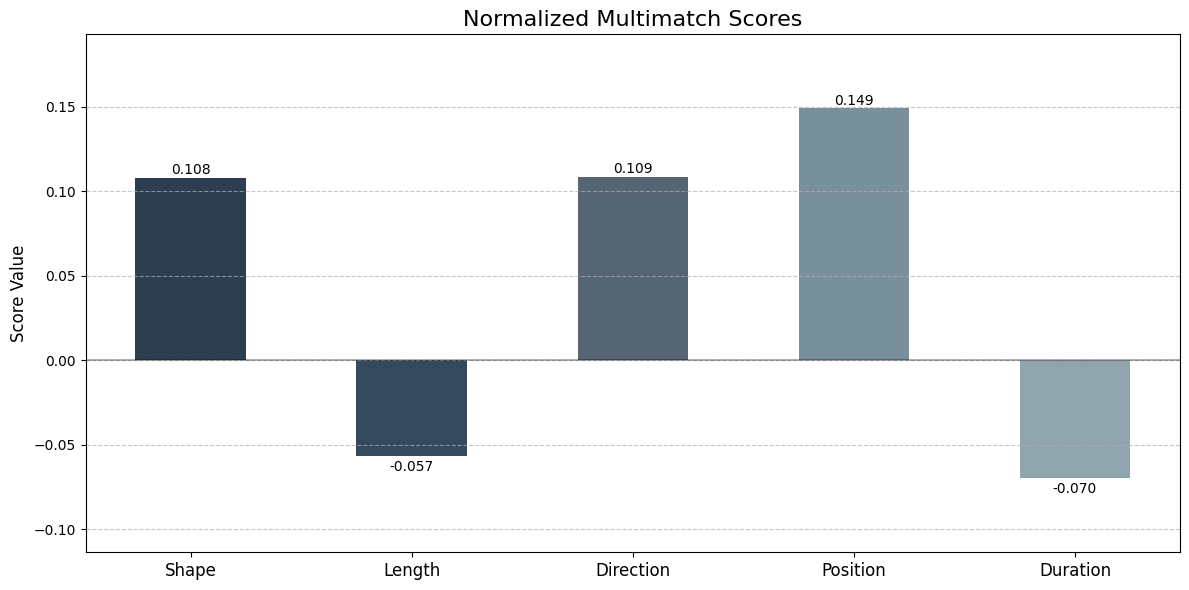

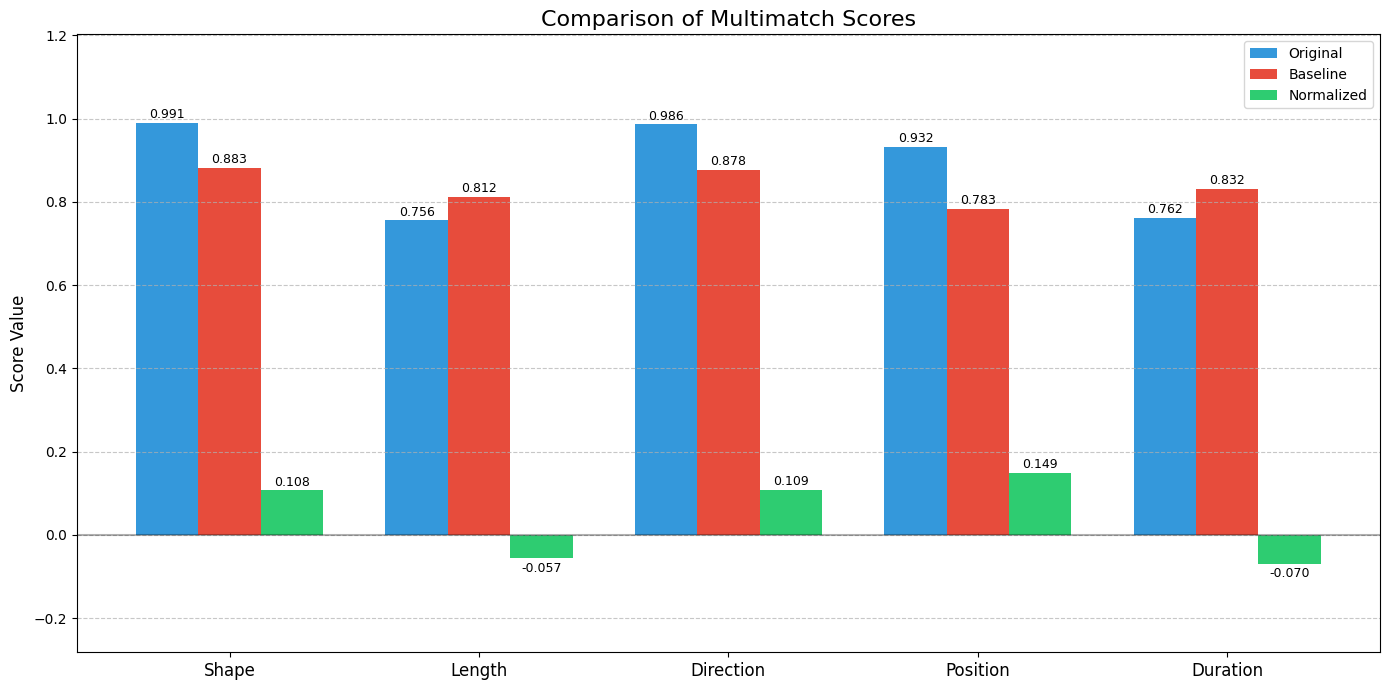

In [15]:
import matplotlib.pyplot as plt

scores = path_similarity.multimatch(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events
)

auxiliary.visualize_multimatch_scores(scores, "Normalized Multimatch Scores")
plt.show()

auxiliary.visualize_all_scores(scores)
plt.show()

Compute path similarity by using scasim (part of ScanDL)

In [16]:
# parameter normalize can be 'durations', 'fixations' or 'None'
# It actually compute Scan path difference
result = path_similarity.scasim(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
    normalize = 'duration'
)

print("Scasim score:", result)

Scasim score: 0.8245013082597275


Compute NLD for both scanpath

In [17]:
distance, nld = path_similarity.nld_for_corrected(exp_a, exp_b, eye_events)

print(f"Distance: {distance}, NLD: {nld}")

Distance: 378.0, NLD: 0.9521410579345088
